In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Hyperbolic Metric

In [11]:
def conformal_factor(z):
    return 2/(1 - np.absolute(z)**2)

def d(z1, z2):
    return np.arccosh(1 + 0.5*conformal_factor(z1)*conformal_factor(z2)*np.absolute(z1-z2)**2)

def build_complex_square(lim_inf=-0.9, lim_max=0.9, num=100):
    t = np.linspace(lim_inf, lim_max, num=num)
    Zreal, Zimag = np.meshgrid(t, t, indexing='xy')
    
    return Zreal + 1j*Zimag

In [6]:
z0 = 0 + 1j*0
complex_square = build_complex_square()

D = d(z0, complex_square)

/tmp/ipykernel_33237/2569353152.py:5: RuntimeWarning: invalid value encountered in arccosh
  return np.arccosh(1 + 0.5*conformal_factor(z1)*conformal_factor(z2)*np.absolute(z1-z2)**2)


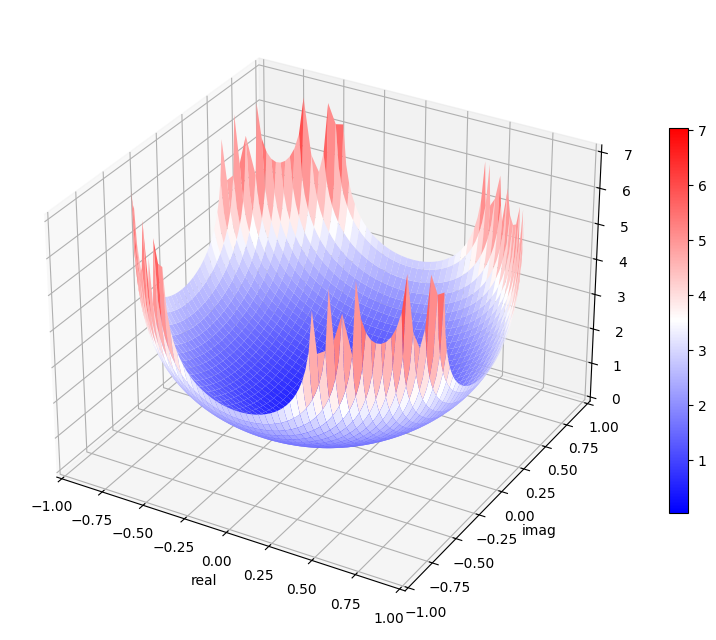

In [7]:
fig, ax = plt.subplots(figsize=(10,10), subplot_kw={'projection': '3d'})

ax.set_xlabel('real')
ax.set_ylabel('imag')

surf = ax.plot_surface(complex_square.real, complex_square.imag, D, cmap='bwr')
fig.colorbar(surf, shrink=0.5)

plt.show()

# Mobius transformations

In [30]:
class Mobius:
    def __init__(self, a, b, c, d):
        if (a*d - b*c) == 0: raise ValueError('Not a valid transformation.')
        
        self.a = a
        self.b = b
        self.c = c
        self.d = d

    def __call__(self, z):
        return (self.a*z + self.b) / (self.c*z + self.d)

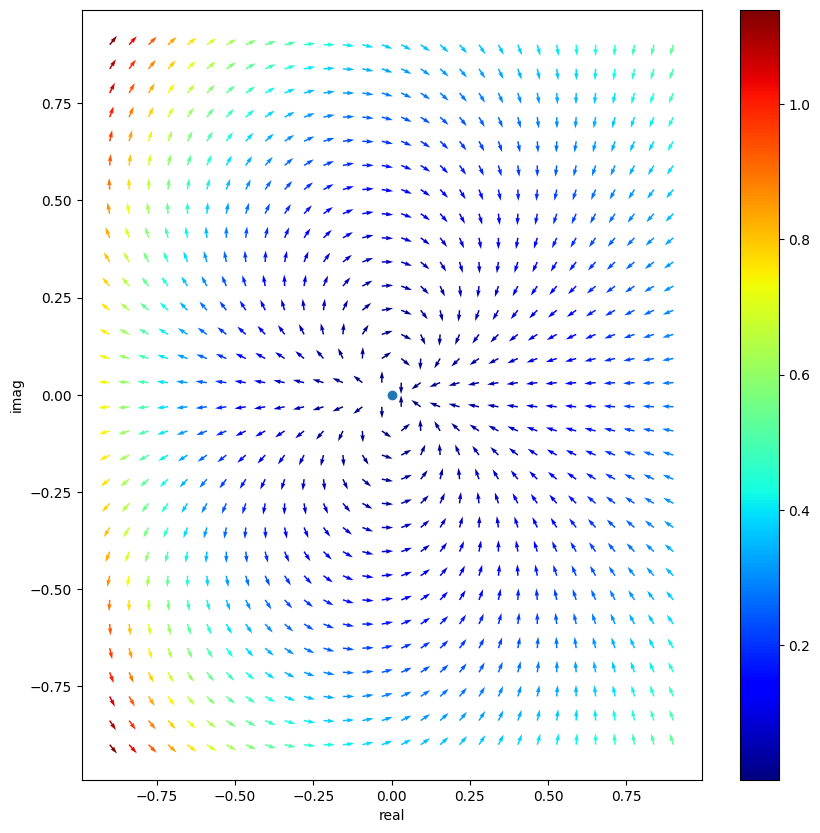

In [54]:
complex_square = build_complex_square(num=30)


a, b = 1, 0
c, d = 0.5, 1

f0 = Mobius(a, b, c, d)
f0_complex_square = f0(complex_square)


X = complex_square.real
Y = complex_square.imag
Xnew = f0_complex_square.real
Ynew = f0_complex_square.imag

U = Xnew - X
V = Ynew - Y

Z = np.absolute(U + 1j*V)


fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel('real')
ax.set_ylabel('imag')

q = ax.quiver(X, Y, U/Z, V/Z, Z, cmap='jet')

ax.plot([0], [0], 'o', )

fig.colorbar(q)
plt.show()

# Laplace-Beltrami